In [1]:
#cell 1
import os
import sys
os.chdir('C:/Project(CSE_155)/retail-digital-twin')
sys.path.append('C:/Project(CSE_155)/retail-digital-twin')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from backend.models.engagement_predictor import EngagementPredictor

print("Module 3 — Engagement Prediction Pipeline")
print("Target: Predict is_buyer from behavioral features")

Module 3 — Engagement Prediction Pipeline
Target: Predict is_buyer from behavioral features


In [2]:
#cell 2
predictor = EngagementPredictor()
df = predictor.load_data('datasets/processed/digital_twins.csv')
predictor.prepare_features(df)

Loaded 1,407,580 Digital Twin profiles
Buyers:     11,719
Non-Buyers: 1,395,861
Imbalance ratio: 1:119

--- Feature Preparation ---
Feature matrix shape: (1407580, 10)
Target distribution:
is_buyer
0    1395861
1      11719
Name: count, dtype: int64

Train set: 1,126,064 samples
Test set:  281,516 samples
Train buyers: 9,375
Test buyers:  2,344


(         total_views  total_addtocarts  total_events  engagement_score  \
 1383160            1                 0             1                 1   
 932839             1                 0             1                 1   
 418771             6                 0             6                 6   
 873472             4                 0             4                 4   
 574446             1                 0             1                 1   
 ...              ...               ...           ...               ...   
 258783             1                 0             1                 1   
 69873              2                 0             2                 2   
 14534              1                 0             1                 1   
 944408             7                 0             7                 7   
 616849             1                 0             1                 1   
 
          view_to_cart_rate  cart_to_purchase_rate  view_to_purchase_rate  \
 1383160             

In [4]:
predictor.train_all_models()


Class weights: {0: np.float64(0.504197677240485), 1: np.float64(60.05674666666667)}
(Higher weight on class 1 = buyers get more attention)

Training Logistic Regression...
  ✓ Done
Training Random Forest...
  ✓ Done
Training XGBoost...
  ✓ Done
Training Gradient Boosting...
  ✓ Done

✅ All 4 models trained


In [5]:
#cell4
results = predictor.evaluate_all_models()


MODEL EVALUATION RESULTS

Logistic Regression
----------------------------------------
  Accuracy    : 1.0
  Precision   : 0.9996
  Recall      : 1.0
  F1 Score    : 0.9998
  ROC-AUC     : 1.0

Random Forest
----------------------------------------
  Accuracy    : 1.0
  Precision   : 1.0
  Recall      : 1.0
  F1 Score    : 1.0
  ROC-AUC     : 1.0

XGBoost
----------------------------------------
  Accuracy    : 1.0
  Precision   : 1.0
  Recall      : 1.0
  F1 Score    : 1.0
  ROC-AUC     : 1.0

Gradient Boosting
----------------------------------------
  Accuracy    : 1.0
  Precision   : 1.0
  Recall      : 1.0
  F1 Score    : 1.0
  ROC-AUC     : 1.0


In [6]:
#cell5
comparison = predictor.get_comparison_table()
print("\n=== FINAL MODEL COMPARISON (Ranked by ROC-AUC) ===\n")
print(comparison.to_string())


=== FINAL MODEL COMPARISON (Ranked by ROC-AUC) ===

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression       1.0     0.9996     1.0    0.9998      1.0
Random Forest             1.0     1.0000     1.0    1.0000      1.0
XGBoost                   1.0     1.0000     1.0    1.0000      1.0
Gradient Boosting         1.0     1.0000     1.0    1.0000      1.0


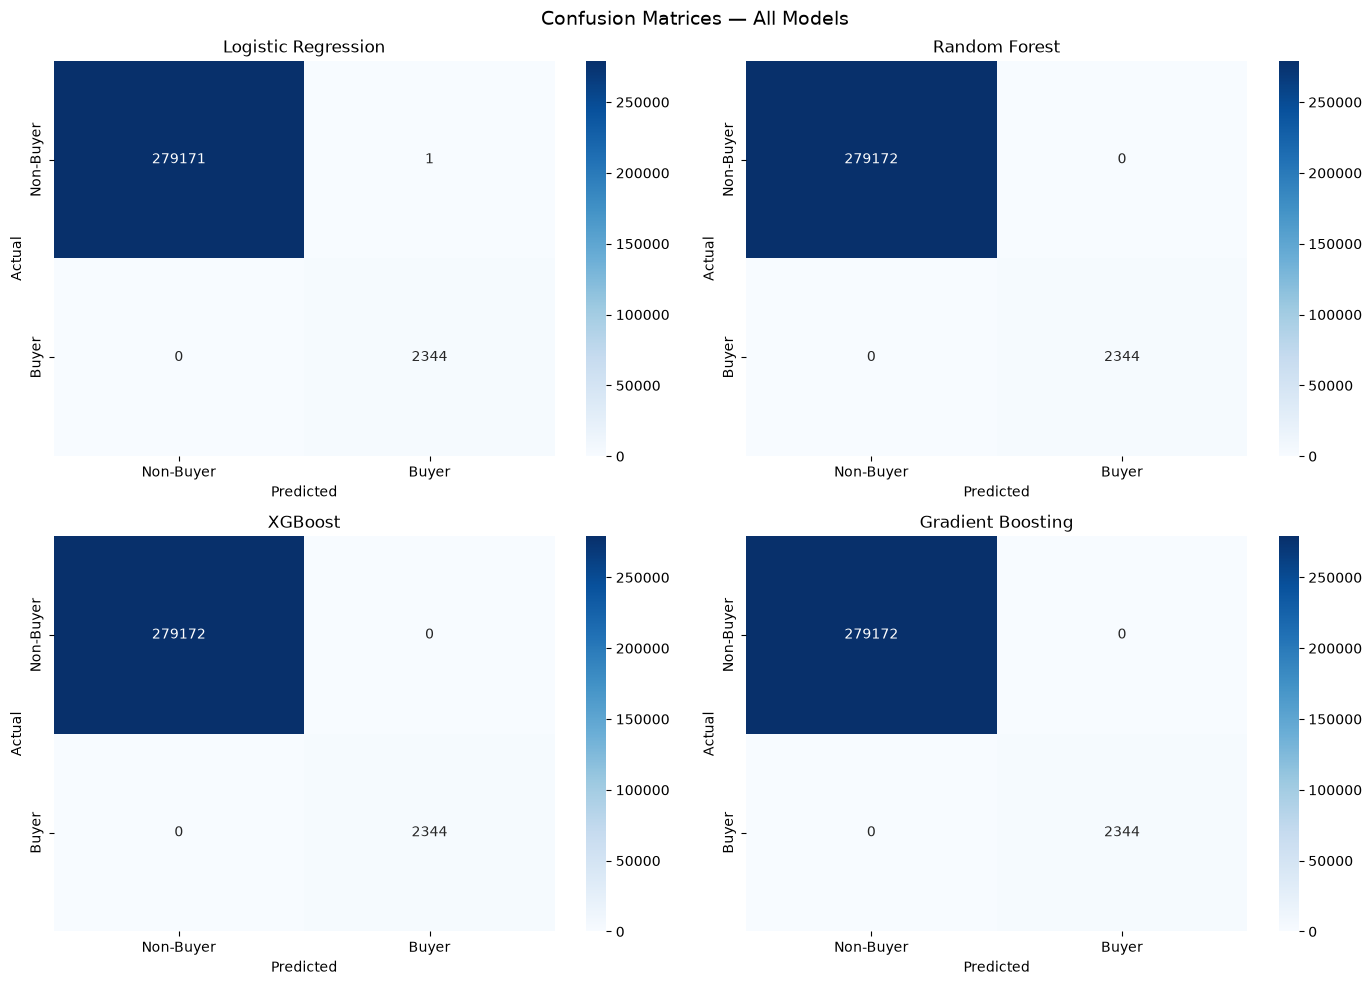

Saved to research/confusion_matrices.png


In [7]:
#cell6
predictor.plot_confusion_matrices()

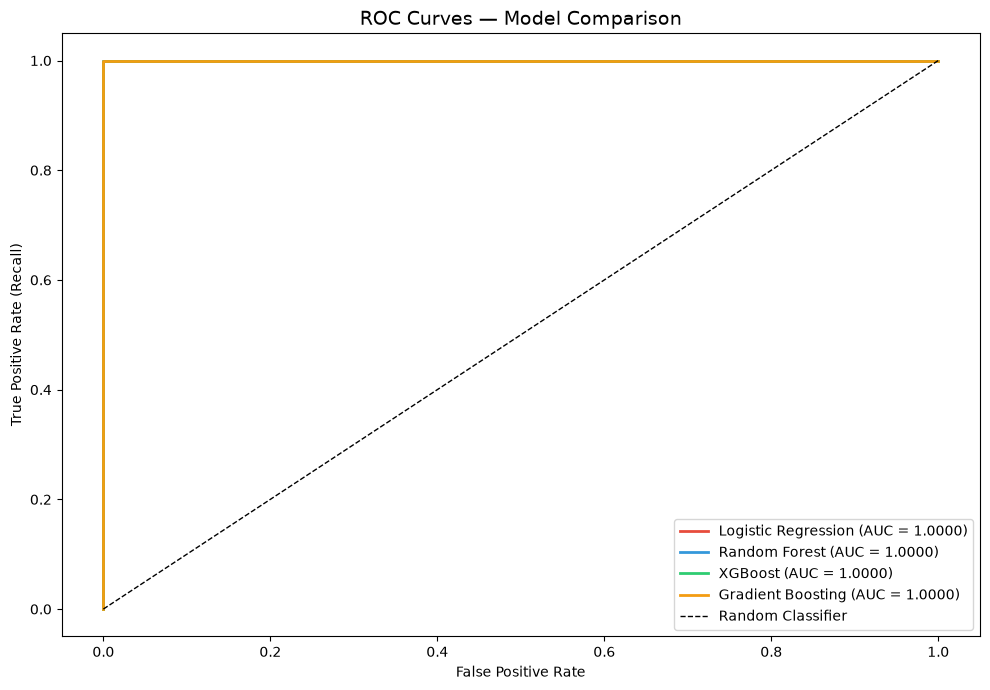

Saved to research/roc_curves.png


In [8]:
#cell7
predictor.plot_roc_curves()

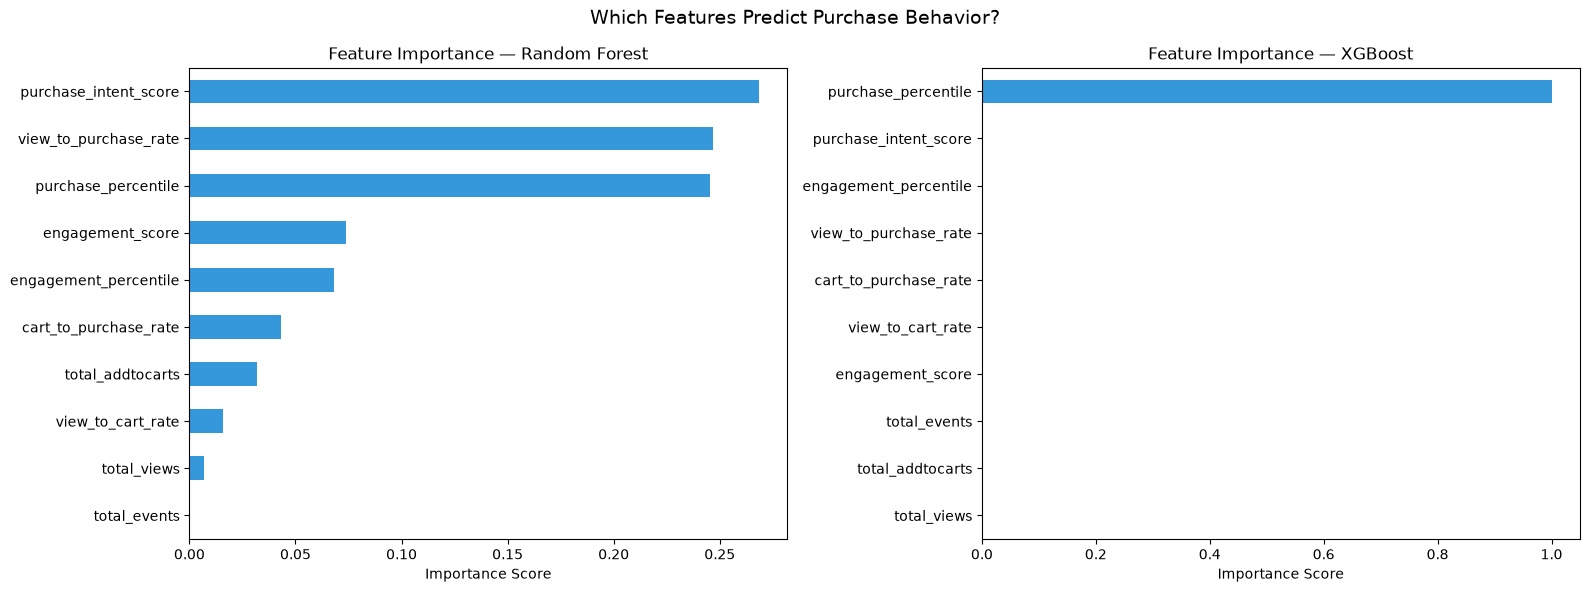

Saved to research/feature_importance.png


In [9]:
#cell8
predictor.plot_feature_importance()

In [10]:
#cell 9
# Use XGBoost — typically strongest on tabular imbalanced data
# We'll confirm after seeing Cell 5 results
enriched_twins = predictor.predict_full_dataset('XGBoost')
enriched_twins.to_csv('datasets/processed/digital_twins_with_predictions.csv', index=False)

print(f"Saved enriched profiles for {len(enriched_twins):,} customers")
print(f"\nPredicted buyers:     {enriched_twins['predicted_buyer'].sum():,}")
print(f"Avg buy probability:  {enriched_twins['buy_probability'].mean():.4f}")
print(f"\nTop 10 customers most likely to buy next:")
top10 = enriched_twins.nlargest(10, 'buy_probability')[
    ['visitorid', 'total_views', 'total_addtocarts',
     'total_purchases', 'buy_probability', 'customer_segment']
]
print(top10.to_string(index=False))

Saved enriched profiles for 1,407,580 customers

Predicted buyers:     11,719
Avg buy probability:  0.0083

Top 10 customers most likely to buy next:
 visitorid  total_views  total_addtocarts  total_purchases  buy_probability customer_segment
       172           33                 3                2              1.0            Buyer
       186            2                 1                1              1.0            Buyer
       264            3                 2                2              1.0            Buyer
       419            4                 1                1              1.0            Buyer
       539            4                 2                1              1.0            Buyer
       627           17                 1                1              1.0            Buyer
       795           14                 1                1              1.0            Buyer
       914            1                 1                1              1.0            Buyer
       964   

In [11]:
#cell 10
print("=" * 60)
print("MODULE 3 — BUSINESS INTELLIGENCE SUMMARY")
print("=" * 60)

high_intent = enriched_twins[enriched_twins['buy_probability'] >= 0.7]
medium_intent = enriched_twins[
    (enriched_twins['buy_probability'] >= 0.3) &
    (enriched_twins['buy_probability'] < 0.7)
]
low_intent = enriched_twins[enriched_twins['buy_probability'] < 0.3]

print(f"\nCustomers by predicted purchase probability:")
print(f"  HIGH   (≥70%):  {len(high_intent):,}  → Priority targets")
print(f"  MEDIUM (30-70%): {len(medium_intent):,}  → Worth nurturing")
print(f"  LOW    (<30%):  {len(low_intent):,}  → Low priority")

never_bought_but_likely = enriched_twins[
    (enriched_twins['is_buyer'] == False) &
    (enriched_twins['buy_probability'] >= 0.5)
]
print(f"\nNon-buyers with ≥50% purchase probability: {len(never_bought_but_likely):,}")
print("→ These are your conversion opportunities")
print("=" * 60)
print("✅ Ready for Module 4: Recommendation Engine")

MODULE 3 — BUSINESS INTELLIGENCE SUMMARY

Customers by predicted purchase probability:
  HIGH   (≥70%):  11,719  → Priority targets
  MEDIUM (30-70%): 0  → Worth nurturing
  LOW    (<30%):  1,395,861  → Low priority

Non-buyers with ≥50% purchase probability: 0
→ These are your conversion opportunities
✅ Ready for Module 4: Recommendation Engine
